# EE4410 - Cyber Security of Power Grids 🔐 ⚡
## Lab 3 🔬 - Cyber-Physical Data Correlation 📉 📉


## Dataset description
#### Physical
  -  IEEE 9-bus dynamic model is implemented as the physical power system using the Real-Time Digital Simulator (RTDS). The topology of the system is shown below.
  - Voltages are saved from EMT simulations and capture the physical response to two different events:
    1. event a
    2. event b
  - The loading of the power system is fixed and any change in its operating condition is the result of an event.

## Cyber
  - Communication network traffic is captured from a digital substation, utilizing a Hardware-in-the-Loop (HIL) testbed
  - Traffic originates from **real protection IEDs** that are connected through a network switch to the RTDS
  - GOOSE traffic throughput (packets/100 ms) is captured using Wireshark.

## Dataset explanation

The datasets contain power system measurements and GOOSE traffic throughput, captured from one substation. Columns are the following:

*   **For the power system measurements**
  1.   Timestamp: Time in seconds
  2.   Voltage magnitudes in per unit

*   **For the OT network traffic throughput**
  1.   Timestamp: Time in seconds
  2.   Network traffic throughput - number of packets per 100 ms

## Student Details
### Name: Zubair Al-Zubi
### ID/number: 5342007

Import libraries

In [7]:
# general imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random
from random import randint
import warnings
import seaborn as sns

# stats model imports
from statsmodels.graphics.tsaplots import plot_acf,plot_pacf
import statsmodels.api as sm
from statsmodels.tsa.arima.model import ARIMA
# supress warning messages
warnings.filterwarnings('ignore')
sns.set_theme()

## Part 1: Familiarization task

Load the dataset

In [8]:
# Read csv files
normal_traffic = pd.read_csv("datasets/normal.csv")
eventa_traffic = pd.read_csv("datasets/event_A_traffic.csv")
eventb_traffic = pd.read_csv("datasets/event_B_traffic.csv")
eventa_volt=pd.read_csv("datasets/event_A_volt.csv")
eventb_volt=pd.read_csv("datasets/event_B_volt.csv")

In [9]:
normal_traffic['numpckt'].describe()

,numpckt
count,380.000000
mean,0.805263
std,1.037031
min,0.000000
25%,0.000000
50%,0.000000
75%,1.000000
max,4.000000


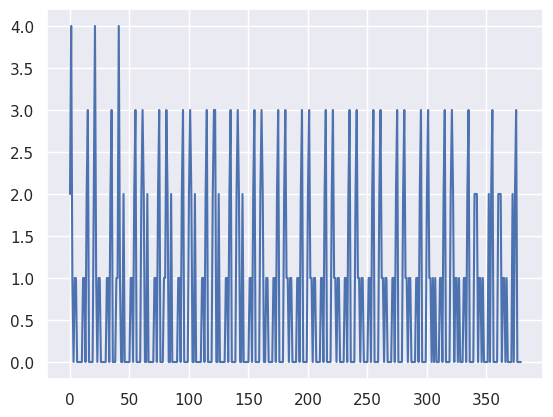

In [10]:
normal_traffic['numpckt'].plot()
plt.savefig('plots/part-1/normal_traffic.svg', format='svg')

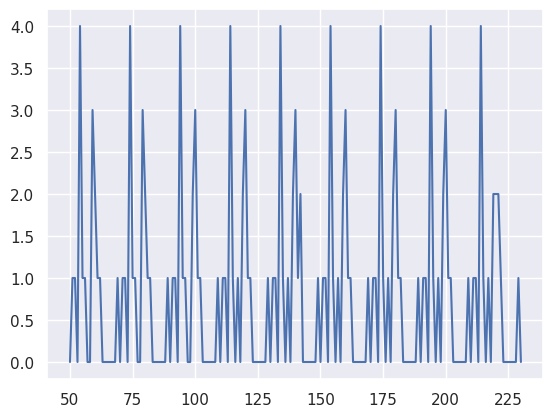

In [11]:
eventa_traffic['numpckt'][50:].plot()
plt.savefig('plots/part-1/event_a_traffic.svg', format='svg')

- visualize the signals in the dataset and see what they represent?
- plot similar visualizations and see how the voltages and event traffic connect with each other

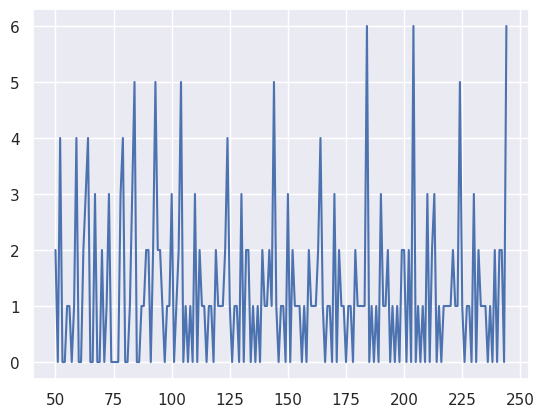

In [12]:
eventb_traffic['numpckt'][50:].plot()
plt.savefig('plots/part-1/event_b_traffic.svg', format='svg')

### Traffic plots
The GOOSE traffic signal `numpckt` data has been plotted for three different scenerios: normal operation, Event A, and Event B.

- Under normal operation: the signal shows regular and sparse activity, mostly ranging between 0 and 3 packets per 100ms.
- Under Event A: the traffic signal shows a structured but slightly denser pattern than normal operation, with bursts reaching up to 4 packets per 100ms.
- Under Event B: the signal shows an irregular and bursty pattern, with packet rates reaching up to 6 packets per 100ms.

### Voltage plots

The voltages at buses 5 to 9 during Event A and Event B have also been plotted below.

- In Event A, there was a sharp and significant drop in voltages across all buses (down to ~0.4 p.u.) at approximately t = 2s, followed by quick recovery and stabilization around t = 5-6s. This may be due to a short-circuit followed by successful breaker operation.
- In Event B, the plot shows a mild but noticeable deviation in voltage beginning around t = 1s, followed by a series of oscillations before stabilizing. This could be due to a minor switching event rather than a physical fault.

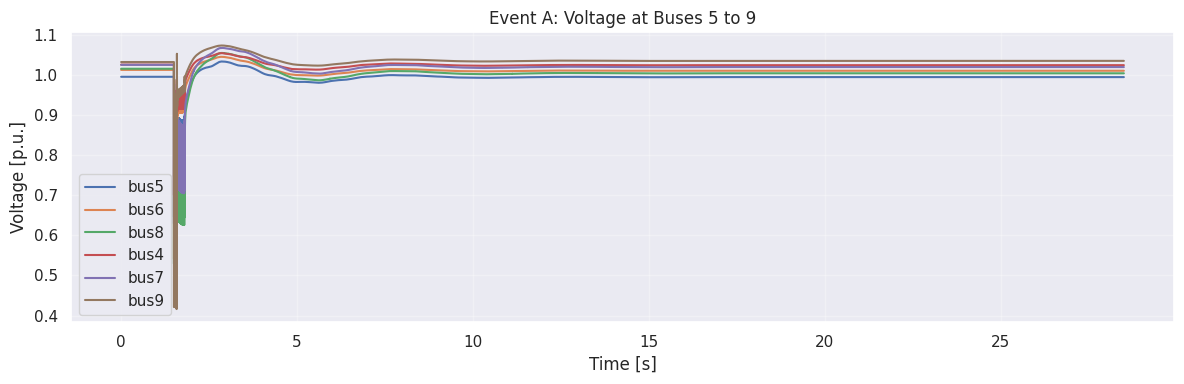

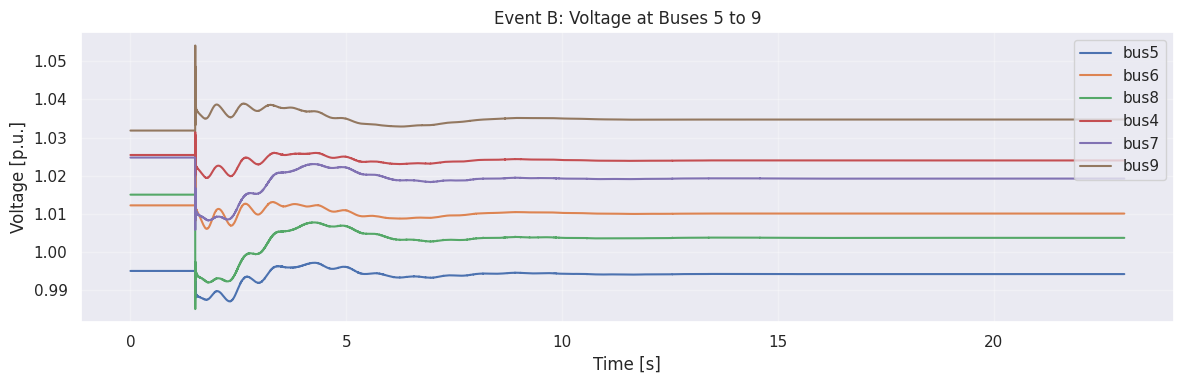

In [13]:
eventa_volt["Time"] = eventa_volt["Time"].astype(float)
eventb_volt["Time"] = eventb_volt["Time"].astype(float)

# Plot Event A voltage across all buses
plt.figure(figsize=(12, 4))
for col in eventa_volt.columns[1:]:
    plt.plot(eventa_volt["Time"], eventa_volt[col], label=col)
plt.title("Event A: Voltage at Buses 5 to 9")
plt.xlabel("Time [s]")
plt.ylabel("Voltage [p.u.]")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('plots/part-1/event_a_voltage.svg', format='svg')
plt.show()

# Plot Event B voltage across all buses
plt.figure(figsize=(12, 4))
for col in eventb_volt.columns[1:]:
    plt.plot(eventb_volt["Time"], eventb_volt[col], label=col)
plt.title("Event B: Voltage at Buses 5 to 9")
plt.xlabel("Time [s]")
plt.ylabel("Voltage [p.u.]")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('plots/part-1/event_b_voltage.svg', format='svg')
plt.show()


## Part 2: Implement correlation techniques/methods

For this lab, it is recomended to use the python [*statsmodel*](https://www.statsmodels.org/stable/index.html) library.

### ARMA model
Model contains $p$ Auto-Regressive (AR) terms and $q$ Moving-Average (MA) terms. The model is given by:

$X_t= \sum_{i=1}^p \varphi_i X_{t-i}+\sum_{i=1}^q \theta_i \varepsilon_{t-i} + \varepsilon_t$

***hint***: to find the right values for $p, q$,  *test* for autocorrelation (MA part) and partial-autocorrelation (for the AR part).

#### ACF and PACF to find optimal $p,q$

The PACF covers the AR and ACF covers the MA part

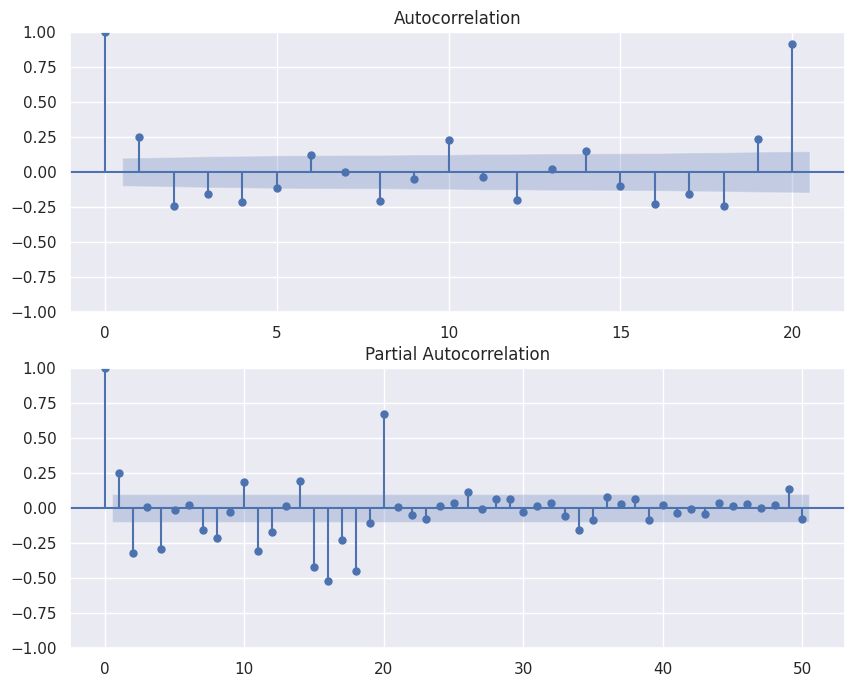

In [14]:
fig = plt.figure(figsize=(10,8))
ax1 = fig.add_subplot(211)
fig = sm.graphics.tsa.plot_acf(normal_traffic['numpckt'].dropna(),lags=20,ax=ax1)

ax2 = fig.add_subplot(212)
fig = sm.graphics.tsa.plot_pacf(normal_traffic['numpckt'].dropna(),lags=50,ax=ax2)

#### Train ARMA/ARIMA model

In [15]:
train_end=200
training = normal_traffic['numpckt'][0:train_end]
testing = normal_traffic['numpckt'][train_end+1:]

- reference to ARIMA function from statsmodel library:
https://www.statsmodels.org/stable/generated/statsmodels.tsa.arima.model.ARIMA.html

-  example ARMA implementation: https://www.statsmodels.org/stable/examples/notebooks/generated/tsa_arma_1.html

In [16]:
# this is an example with some random values of p,q to highlight the implementation.
# modify this part with your p,q values.
p= 1
q= 2
# here we define the ARMA model to be trained on our training samples.
# This is an ARMA(p,q) model
model=ARIMA(training,order=(p,0,q)) # p, d, q. we set d=0 since there is no differencing to be applied.
# train the model on the training dataset
model_fit=model.fit()
print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                numpckt   No. Observations:                  200
Model:                 ARIMA(1, 0, 2)   Log Likelihood                -260.760
Date:                Sat, 31 May 2025   AIC                            531.520
Time:                        22:36:45   BIC                            548.011
Sample:                             0   HQIC                           538.194
                                - 200                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.8047      0.004    179.171      0.000       0.796       0.814
ar.L1          0.5564      0.088      6.356      0.000       0.385       0.728
ma.L1         -0.3920     13.768     -0.028      0.9

#### Forecast/predict using ARMA

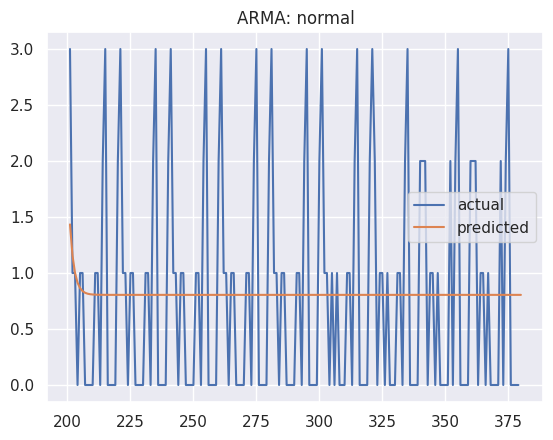

In [50]:
t1=train_end+1
t2= len(normal_traffic['numpckt'])
# here we predict the remaining samples using the trained ARMA model
forecast=model_fit.predict(start=t1,end=t2, dynamic=True)
# plot the actual signal
testing.plot()
# plot the predicted values
forecast.plot()
plt.legend(['actual','predicted'])
plt.title('ARMA: normal')
plt.savefig('plots/part-2/normal_arma.svg', format='svg')

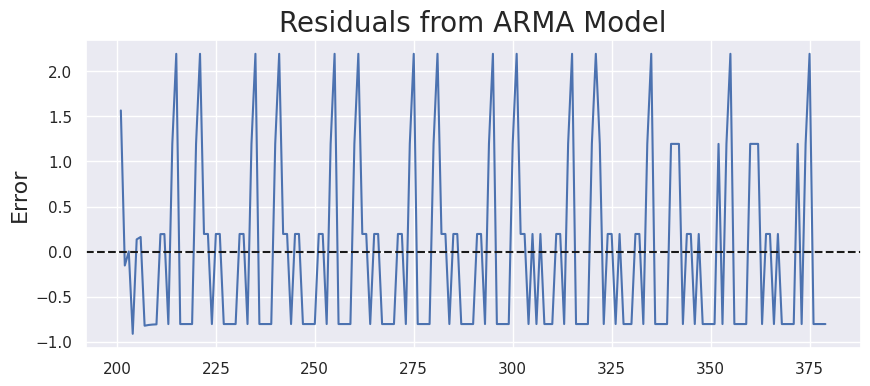

In [51]:
# here we plot the residuals, i.e.,  differences between the actual and predicted values
# ideally, the residual ~=0

# plot the residuals/errors
residuals = testing- forecast
plt.figure(figsize=(10,4))
plt.plot(residuals)
plt.axhline(0, linestyle='--', color='k')
plt.title('Residuals from ARMA Model', fontsize=20)
plt.ylabel('Error', fontsize=16)
plt.savefig('plots/part-2/normal_residuals.svg', format='svg')

using the trained ARMA model, we repeat only the predictions for events a and b and plot the corresponding residuals as shown below

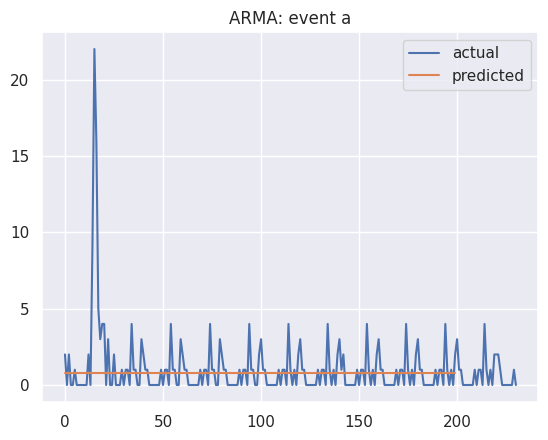

In [48]:
# comparison of predicted values vs entire series 'event a traffic'
forecast_a=model_fit.predict(dynamic=True)
eventa_traffic['numpckt'].plot()
forecast_a.plot()
plt.legend(['actual','predicted'])
plt.title('ARMA: event a')
plt.savefig('plots/part-2/event_a_arma.svg', format='svg')

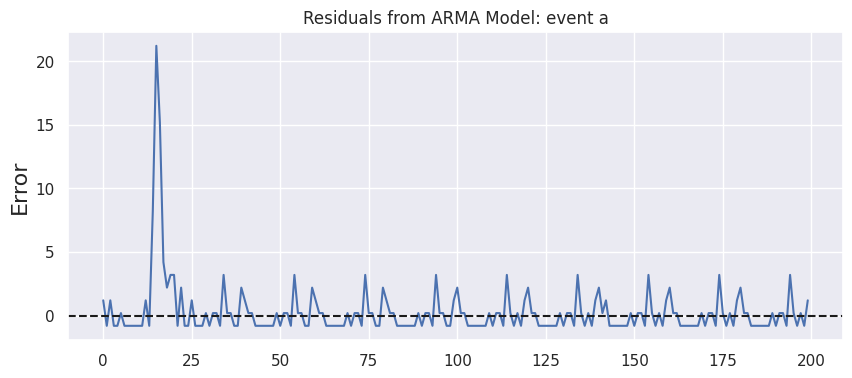

In [49]:
residuals = eventa_traffic['numpckt']- forecast_a
plt.figure(figsize=(10,4))
plt.plot(residuals)
plt.axhline(0, linestyle='--', color='k')
plt.title('Residuals from ARMA Model: event a', fontsize=12)
plt.ylabel('Error', fontsize=16)
plt.savefig('plots/part-2/event_a_residuals.svg', format='svg')

please repeat for event b


#### **Event B**

##### Predict values for Event B using ARMA

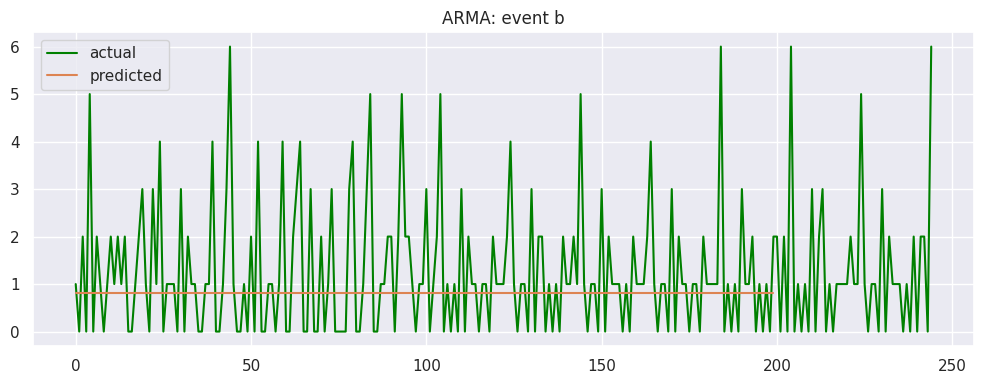

In [46]:
# Predict values for Event B traffic using ARMA model trained on normal traffic
forecast_b = model_fit.predict(dynamic=True)

# Plot actual vs predicted values for Event B
plt.figure(figsize=(10, 4))
eventb_traffic['numpckt'].plot(label='actual', color='green')
forecast_b[:len(eventb_traffic)].plot(label='predicted', color='C01')
plt.legend()
plt.title('ARMA: event b')
plt.tight_layout()
plt.savefig('plots/part-2/event_b_arma.svg', format='svg')
plt.show()


##### Residuals for Event B

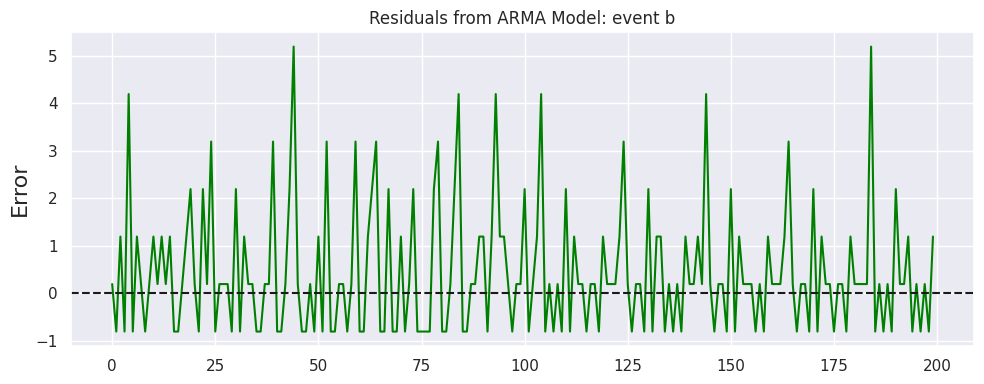

In [47]:
# Calculate and plot residuals for Event B
residuals_b = eventb_traffic['numpckt'] - forecast_b[:len(eventb_traffic)]

plt.figure(figsize=(10, 4))
plt.plot(residuals_b, color='green')
plt.axhline(0, linestyle='--', color='k')
plt.title('Residuals from ARMA Model: event b', fontsize=12)
plt.ylabel('Error', fontsize=16)
plt.tight_layout()
plt.savefig('plots/part-2/event_b_residuals.svg', format='svg')
plt.show()


### Train SARMA model

the API reference of the SARMA class: https://www.statsmodels.org/dev/generated/statsmodels.tsa.statespace.sarimax.SARIMAX.html

In [22]:
# define the weights for the SARMA. These are just some example values to highlight implementation.
p=1
q=2
d=0

P=1
D=0
Q=2
s=4
# define and train the SARMA model
model=sm.tsa.statespace.SARIMAX(training, order=(p,d,q), seasonal_order=(P,D,Q,s))
results=model.fit()

In [23]:
# results from SARMA model
print(results.summary())

                                     SARIMAX Results                                     
Dep. Variable:                           numpckt   No. Observations:                  200
Model:             SARIMAX(1, 0, 2)x(1, 0, 2, 4)   Log Likelihood                -266.439
Date:                           Sat, 31 May 2025   AIC                            546.879
Time:                                   22:36:48   BIC                            569.967
Sample:                                        0   HQIC                           556.222
                                           - 200                                         
Covariance Type:                             opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.5473      0.198      2.766      0.006       0.159       0.935
ma.L1         -0.3599      0.177     -2.038

#### Forecast using SARMA

Text(0.5, 1.0, 'SARMA: normal')

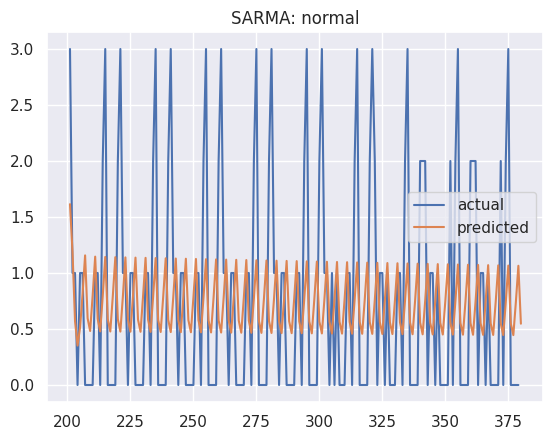

In [24]:
forecast_sarma=results.predict(start=t1,end=t2, dynamic=True)
# plot the actual signal
testing.plot()
# plot the predicted values
forecast_sarma.plot()
plt.legend(['actual','predicted'])
plt.title('SARMA: normal')

Text(0, 0.5, 'Error')

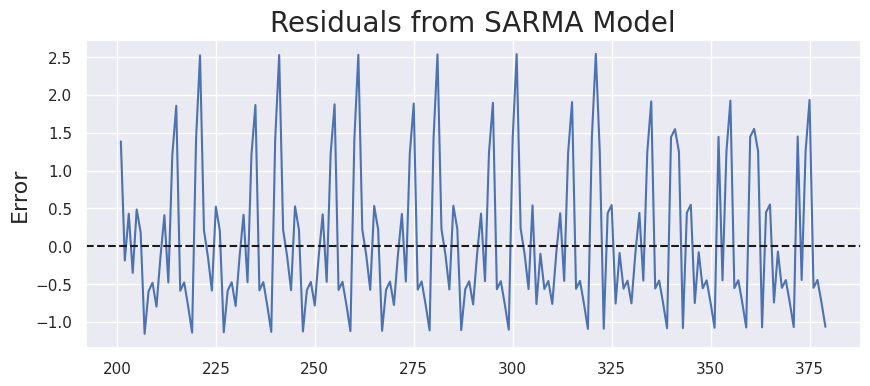

In [25]:
# plot the residuals/errors
residuals = testing- forecast_sarma
plt.figure(figsize=(10,4))
plt.plot(residuals)
plt.axhline(0, linestyle='--', color='k')
plt.title('Residuals from SARMA Model', fontsize=20)
plt.ylabel('Error', fontsize=16)

## Assignment 📚

### Part 1: Familiarization and data visualization

Load the provided dataset and explore it. Try to answer/investigate the following:
  1. What types of signals are present? What parameters do they represent?
  2. Are the signals correlated? Do they show any periodic behaviour?
  3. What types of events do you think are captured in the provided datasets?

Justify your answers with visualizations/plots.



### Part 2: ARMA model

1. Train an ARMA model on the `normal traffic` dataset using the `statsmodel` library by choosing a training range of samples, for example, between $ 0~to~100 $ samples.
 - *hint:* you can also use a 80-20 split for training and testing, respectively.
2. Use the trained ARMA model, predict the rest of the `normal traffic` dataset and plot the residuals/differences between the actual values and predicted values.
3. What do you observe? Try to vary the values of $p, q$ and reflect on the prediction performance.

  - ***hint***: to find the optimal values for $p, q$,  plot autocorrelations (MA part) and partial-autocorrelations (for the AR part).

4. Using the above trained ARMA model
predict values of identified event cases from part 1.
  - Plot the residuals/differences between the actual values and predicted values and correlate with the voltages. What do you observe w.r.t to the different events?

**Note**: try to limit the time window for prediction to a few samples and compare with actual signal (ground-truth).

### Part 3: SARMA model

1. Train a SARMA model instead of ARMA and repeat the above analysis. What can you comment on the prediction performance of SARMA compared to the ARIMA model?

2.  ***When and why*** should one go for SARMA models instead of ARMA? Justify your answer based on the above analysis.